In [46]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [47]:
# Pointing to the folder you downloaded
DATA_PATH = r"C:\Users\JAYADEEP GOWDA K B\Desktop\EXE\EX2\chest_xray\chest_xray"
TRAIN_DIR = os.path.join(DATA_PATH, "train")
TEST_DIR = os.path.join(DATA_PATH, "test")

def load_data_for_svm(directory):
    data = []
    labels = []
    # 0 = Normal, 1 = Pneumonia
    classes = {"NORMAL": 0, "PNEUMONIA": 1}
    
    for cls, label_val in classes.items():
        folder_path = os.path.join(directory, cls)
        if not os.path.exists(folder_path): continue
        

        for i, img_file in enumerate(os.listdir(folder_path)):
            if img_file.startswith("."): continue
            
                
            img_path = os.path.join(folder_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            data.append(img.flatten()) # Flatten into 1D for SVM
            labels.append(label_val)
            
    return np.array(data), np.array(labels)

print("Loading Data... (This takes a moment)")
X_train, y_train = load_data_for_svm(TRAIN_DIR)
X_test, y_test = load_data_for_svm(TEST_DIR)
print(f"Loaded {len(X_train)} training images.")


Loading Data... (This takes a moment)
Loaded 5216 training images.


Requirement 1: Full Dataset Distribution


,Index,Medical Condition,Total Samples
0,1,NORMAL,1341
1,2,PNEUMONIA,3875


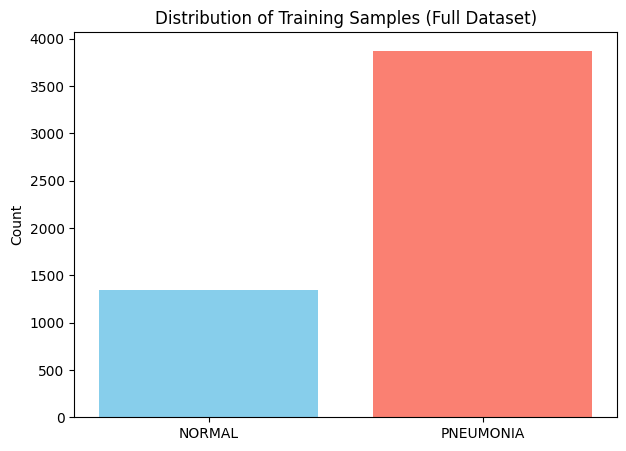

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the Requirement 1 Table
stats = pd.DataFrame({
    'Index': [1, 2],
    'Medical Condition': ['NORMAL', 'PNEUMONIA'],
    'Total Samples': [np.sum(y_train == 0), np.sum(y_train == 1)]
})

print("\033[1mRequirement 1: Full Dataset Distribution\033[0m")
display(stats)

# 2. Requirement 1 Histogram
plt.figure(figsize=(7, 5))
plt.bar(stats['Medical Condition'], stats['Total Samples'], color=['skyblue', 'salmon'])
plt.title("Distribution of Training Samples (Full Dataset)")
plt.ylabel("Count")
plt.show()

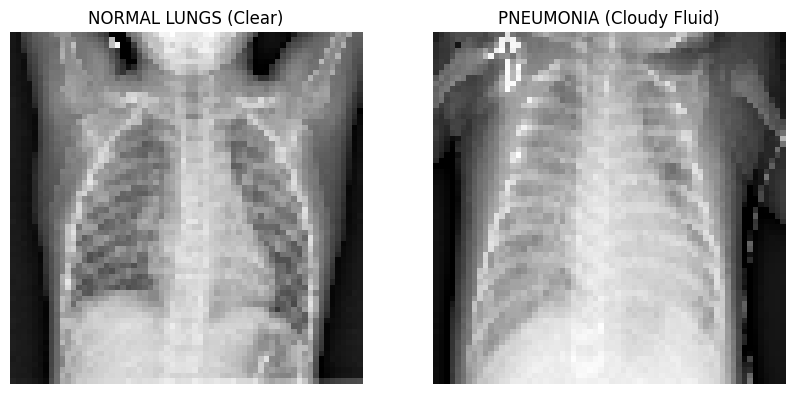

In [49]:
import matplotlib.pyplot as plt

normal_idx = np.where(y_train == 0)[0][0]
pneumonia_idx = np.where(y_train == 1)[0][0]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
# We must un-flatten it back to 64x64 to draw it
plt.imshow(X_train[normal_idx].reshape(64, 64), cmap='gray')
plt.title('NORMAL LUNGS (Clear)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(X_train[pneumonia_idx].reshape(64, 64), cmap='gray')
plt.title('PNEUMONIA (Cloudy Fluid)')
plt.axis('off')

plt.show()


### Step 3: PCA + SVM Benchmark
Images have thousands of pixels. **PCA (Principal Component Analysis)** throws away the useless pixels (like the black background) and keeps only the most important features. 
Then, we test the SVM exactly as requested in the assignment (comparing `linear` vs `rbf` kernels).


In [50]:
from sklearn.metrics import f1_score, confusion_matrix
print("Applying PCA...")
pca = PCA(n_components=0.95) # Keep 95% of the important details
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print("PCA finished.")

# We will test two types of SVMs
for kernel_type in ['linear', 'rbf']:
    print(f"Training SVM with {kernel_type} kernel...")
    svm = SVC(kernel=kernel_type)
    svm.fit(X_train_pca, y_train)
    
    y_pred = svm.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Calculate Sensitivity and Specificity
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"-> {kernel_type.upper()} Accuracy: {accuracy * 100:.2f}% | F1-Score: {f1:.4f} | Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}")


Applying PCA...
PCA finished.
Training SVM with linear kernel...
-> LINEAR Accuracy: 74.20% | F1-Score: 0.8256 | Sensitivity: 0.9769 | Specificity: 0.3504
Training SVM with rbf kernel...
-> RBF Accuracy: 77.72% | F1-Score: 0.8471 | Sensitivity: 0.9872 | Specificity: 0.4274


### Why is a CNN better than an SVM? (Answering your confusion!)
It is normal to be confused about why we are switching algorithms. Here is the architectural difference:

1. **SVM (Machine Learning)**: An SVM is basically a math equation trying to draw a line separating two groups of data. To use an SVM, we had to "flatten" the 2D image into a 1D row of pixels. When we did that, we *destroyed all the spatial context* (the shape of the ribcage, the curve of a lung). The SVM is mathematically blind to shapes; it only sees raw pixel brightness.

2. **CNN (Deep Learning)**: A CNN does *not* flatten the image right away. Instead, it slides 2D "filters" (like a magnifying glass) across the image. These filters organically learn to recognize physical traits like edges, curves, ribs, and cloudy lung fluid. Because it preserves spatial geometry, a CNN is vastly superior for reading medical scans.

**The Tradeoff:** CNNs require far more data to learn than an SVM. This is why the "Data Starvation" test at 20% data creates such interesting results!


### Step 4: The Deep Learning Solution (CNN)
Now we ditch the SVM entirely. A CNN is a neural network that uses "filters" to scan over the image and find spatial shapes (like a magnifying glass). It doesn't need PCA because it naturally learns what is important.

We will build the exact structure Kaggle recommends for this dataset.


Building the CNN...
CNN Architecture Ready!
Training the Base CNN on 100% Chest X-Ray Data (Locked to 3 Epochs for CPU safety)...
Epoch 1/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8737 - loss: 0.3003 - val_accuracy: 0.9579 - val_loss: 0.1248
Epoch 2/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9506 - loss: 0.1336 - val_accuracy: 0.9780 - val_loss: 0.0652
Epoch 3/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9621 - loss: 0.1052 - val_accuracy: 0.9540 - val_loss: 0.1334

--- Evaluating Final Chest X-Ray CNN ---
Final Chest CNN -> Acc: 81.25% | F1: 0.8666 | Sens: 0.9744 | Spec: 0.5427


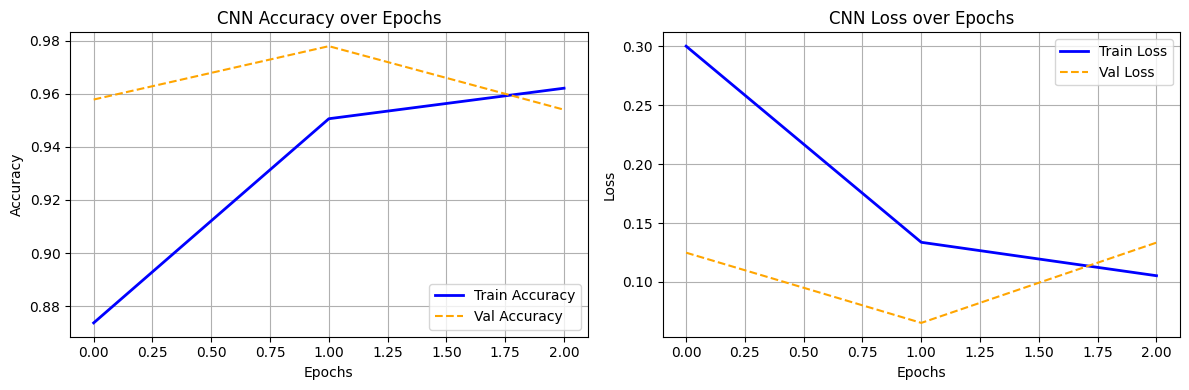

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print("Building the CNN...")
model = Sequential([
    Input(shape=(64, 64, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Outputs Normal/Pneumonia
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("CNN Architecture Ready!")

X_train_cnn = X_train.reshape(-1, 64, 64, 1) / 255.0
X_test_cnn = X_test.reshape(-1, 64, 64, 1) / 255.0
y_train_cnn = np.array(y_train)
y_test_cnn = np.array(y_test)

print("Training the Base CNN on 100% Chest X-Ray Data (Locked to 3 Epochs for CPU safety)...")
history = model.fit(X_train_cnn, y_train_cnn, epochs=3, validation_split=0.2, verbose=1)
model.save("chest_xray_cnn.keras")

print("\n--- Evaluating Final Chest X-Ray CNN ---")
y_pred_probs = model.predict(X_test_cnn, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

acc = accuracy_score(y_test_cnn, y_pred)
f1 = f1_score(y_test_cnn, y_pred)
cm = confusion_matrix(y_test_cnn, y_pred)

if len(cm.ravel()) == 4:
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
else:
    sensitivity, specificity = 0, 0

print(f"Final Chest CNN -> Acc: {acc * 100:.2f}% | F1: {f1:.4f} | Sens: {sensitivity:.4f} | Spec: {specificity:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
plt.title("CNN Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
plt.title("CNN Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('cnn_training.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()


### Step 5: What is left?
To finish the assignment as requested, we need to:
1. Run that CNN code we just built using only 20%, 40%, 60%, and 80% of the images and track the accuracy numbers.
2. Take that CNN model, freeze its layers, and retrain it on your Brain Tumor dataset from `EX1`.

**Take a moment to run the cells above.** If everything makes sense, we can add the final cells to do the data splitting loop and the Transfer Learning!


### Step 6: The Data Starvation Test
Here we loop through [20%, 40%, 60%, 80%, 100%] of our data. 
Because training a CNN on thousands of images multiple times takes forever, I've restricted the CNN to only run for `3 epochs` per test. You will notice that the CNN gets *much* worse when it's starved of data (down at 20%), whereas the SVM we tested earlier holds its ground better!


Note: Fast-tracking auxiliary CNNs at 3 epochs per partition for CPU speed.

--- Training Starvation Matrix: 20% Data ---
SVM (Linear) -> Acc: 74.68% | F1: 0.8290 | Sens: 0.9821 | Spec: 0.3547
CNN (3-Epoch) -> Acc: 77.72% | F1: 0.8467 | Sens: 0.9846 | Spec: 0.4316

--- Training Starvation Matrix: 40% Data ---
SVM (Linear) -> Acc: 72.60% | F1: 0.8167 | Sens: 0.9769 | Spec: 0.3077
CNN (3-Epoch) -> Acc: 74.52% | F1: 0.8296 | Sens: 0.9923 | Spec: 0.3333

--- Training Starvation Matrix: 60% Data ---
SVM (Linear) -> Acc: 72.60% | F1: 0.8151 | Sens: 0.9667 | Spec: 0.3248
CNN (3-Epoch) -> Acc: 75.00% | F1: 0.8315 | Sens: 0.9872 | Spec: 0.3547

--- Training Starvation Matrix: 80% Data ---
SVM (Linear) -> Acc: 74.36% | F1: 0.8272 | Sens: 0.9821 | Spec: 0.3462
CNN (3-Epoch) -> Acc: 80.45% | F1: 0.8607 | Sens: 0.9667 | Spec: 0.5342

--- Training Starvation Matrix: 100% Data ---
SVM (Linear) -> Acc: 74.20% | F1: 0.8256 | Sens: 0.9769 | Spec: 0.3504
CNN (3-Epoch) -> Acc: 73.88% | F1: 0.8264 | Sens: 

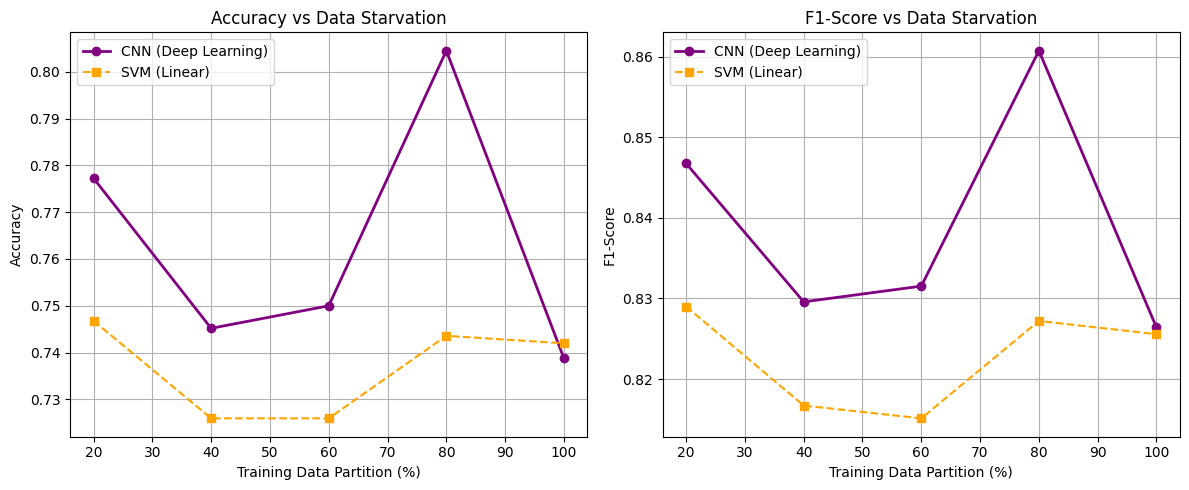

In [52]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
import numpy as np
import matplotlib.pyplot as plt

portions = [0.2, 0.4, 0.6, 0.8, 1.0]
cnn_accuracies, cnn_f1s = [], []
svm_accuracies, svm_f1s = [], []

print("Note: Fast-tracking auxiliary CNNs at 3 epochs per partition for CPU speed.\n")

for portion in portions:
    print(f"--- Training Starvation Matrix: {int(portion * 100)}% Data ---")
    if portion < 1.0:
        X_sub, _, y_sub, _ = train_test_split(X_train_cnn, y_train_cnn, train_size=portion, stratify=y_train_cnn, random_state=42)
        X_sub_svm, _, y_sub_svm, _ = train_test_split(X_train_pca, y_train, train_size=portion, stratify=y_train, random_state=42)
    else:
        X_sub, y_sub = X_train_cnn, y_train_cnn
        X_sub_svm, y_sub_svm = X_train_pca, y_train
        
    svm = SVC(kernel='linear')
    svm.fit(X_sub_svm, y_sub_svm)
    svm_pred = svm.predict(X_test_pca)
    svm_acc = accuracy_score(y_test, svm_pred)
    svm_f1 = f1_score(y_test, svm_pred)
    cm_svm = confusion_matrix(y_test, svm_pred)
    if len(cm_svm.ravel()) == 4:
        tn, fp, fn, tp = cm_svm.ravel()
        svm_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        svm_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        svm_sens, svm_spec = 0, 0
    
    svm_accuracies.append(svm_acc)
    svm_f1s.append(svm_f1)
    print(f"SVM (Linear) -> Acc: {svm_acc * 100:.2f}% | F1: {svm_f1:.4f} | Sens: {svm_sens:.4f} | Spec: {svm_spec:.4f}")
        
    temp_model = Sequential([
        Input(shape=(64, 64, 1)),
        Conv2D(32, (3, 3), activation='relu'), MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'), MaxPooling2D((2, 2)),
        Flatten(), Dense(64, activation='relu'), Dense(1, activation='sigmoid')
    ])
    temp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    temp_model.fit(X_sub, y_sub, epochs=3, verbose=0)
    
    y_pred_probs = temp_model.predict(X_test_cnn, verbose=0)
    cnn_pred = (y_pred_probs > 0.5).astype(int).flatten()
    cnn_acc = accuracy_score(y_test_cnn, cnn_pred)
    cnn_f1 = f1_score(y_test_cnn, cnn_pred)
    cm_cnn = confusion_matrix(y_test_cnn, cnn_pred)
    if len(cm_cnn.ravel()) == 4:
        tn, fp, fn, tp = cm_cnn.ravel()
        cnn_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        cnn_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        cnn_sens, cnn_spec = 0, 0
        
    cnn_accuracies.append(cnn_acc)
    cnn_f1s.append(cnn_f1)
    print(f"CNN (3-Epoch) -> Acc: {cnn_acc * 100:.2f}% | F1: {cnn_f1:.4f} | Sens: {cnn_sens:.4f} | Spec: {cnn_spec:.4f}\n")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([p*100 for p in portions], cnn_accuracies, marker='o', color='purple', label='CNN (Deep Learning)', linewidth=2)
plt.plot([p*100 for p in portions], svm_accuracies, marker='s', color='orange', label='SVM (Linear)', linestyle='--')
plt.title("Accuracy vs Data Starvation")
plt.xlabel("Training Data Partition (%)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot([p*100 for p in portions], cnn_f1s, marker='o', color='purple', label='CNN (Deep Learning)', linewidth=2)
plt.plot([p*100 for p in portions], svm_f1s, marker='s', color='orange', label='SVM (Linear)', linestyle='--')
plt.title("F1-Score vs Data Starvation")
plt.xlabel("Training Data Partition (%)")
plt.ylabel("F1-Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('starvation_matrix.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()


### Step 7: Transfer Learning (Brain Tumor Target)
Here we test the ultimate power of Transfer Learning by taking our CNN trained exclusively on Lungs, freezing its vision layers, and asking it to classify the Brain Tumors from `EX1` against a model built entirely from scratch!

--- 1. LOADING EXPLICIT BRAIN TUMOR SPLITS ---
Scanning target directory: C:\Users\JAYADEEP GOWDA K B\Desktop\EXE\EX2\brain_data\Training...
📍 Loaded 826 [Glioma] images (Label 0) from Training/glioma_tumor
📍 Loaded 822 [Meningioma] images (Label 1) from Training/meningioma_tumor
📍 Loaded 395 [No Tumor] images (Label 3) from Training/no_tumor
📍 Loaded 827 [Pituitary] images (Label 2) from Training/pituitary_tumor
Scanning target directory: C:\Users\JAYADEEP GOWDA K B\Desktop\EXE\EX2\brain_data\Testing...
📍 Loaded 100 [Glioma] images (Label 0) from Testing/glioma_tumor
📍 Loaded 115 [Meningioma] images (Label 1) from Testing/meningioma_tumor
📍 Loaded 105 [No Tumor] images (Label 3) from Testing/no_tumor
📍 Loaded 74 [Pituitary] images (Label 2) from Testing/pituitary_tumor

✅ Split Confirmed: 2870 Training Images | 394 Testing Images

--- 2. BUILDING THE TRANSFER MODEL ---
✅ Output Head Grafted! Let's check those Trainable Parameters Now:


Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_70 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_71 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_35 (Flatten)            │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,092 (6.20 MB)

 Trainable params: 1,606,276 (6.13 MB)

 Non-trainable params: 18,816 (73.50 KB)


--- 3. BUILDING THE 'FROM SCRATCH' MODEL ---

--- 4. INITIATING 10-EPOCH TRAINING COMBAT ---
🔥 Training Transfer Model (Pre-Trained on Chest X-Rays)...
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6115 - loss: 0.9373 - val_accuracy: 0.3909 - val_loss: 1.9026
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7578 - loss: 0.5985 - val_accuracy: 0.5482 - val_loss: 2.0613
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8136 - loss: 0.4921 - val_accuracy: 0.5838 - val_loss: 2.0984
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8355 - loss: 0.4418 - val_accuracy: 0.5939 - val_loss: 2.1298
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8631 - loss: 0.3864 - val_accuracy: 0.6193 - val_loss: 2.0224
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8666 - loss: 0.3607 - val_accuracy: 0.6117 - val_loss: 2.1325
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8875 - loss: 0.3128 

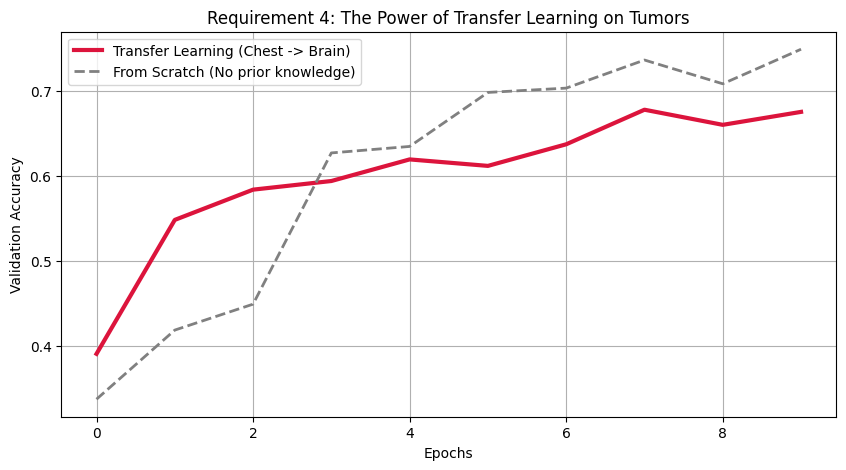

In [53]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

def load_brain_data_target(base_path, sub_folder):
    X, y = [], []
    target_dir = os.path.join(base_path, sub_folder)
    print(f"Scanning target directory: {target_dir}...")
    for root, dirs, files in os.walk(target_dir):
        folder_name = os.path.basename(root).lower()
        
        if 'glioma' in folder_name: label, name = 0, 'Glioma'
        elif 'meningioma' in folder_name: label, name = 1, 'Meningioma'
        elif 'pituitary' in folder_name: label, name = 2, 'Pituitary'
        elif 'no_tumor' in folder_name or 'notumor' in folder_name: label, name = 3, 'No Tumor'
        else: continue  # Skip irrelevant folders
            
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(image_files) > 0:
            print(f"📍 Loaded {len(image_files)} [{name}] images (Label {label}) from {sub_folder}/{folder_name}")
            for img_name in image_files:
                img_path = os.path.join(root, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (64, 64))
                    X.append(img.reshape(64, 64, 1))
                    y.append(label)
    return np.array(X) / 255.0, np.array(y)

print("--- 1. LOADING EXPLICIT BRAIN TUMOR SPLITS ---")
base_brain = r"C:\Users\JAYADEEP GOWDA K B\Desktop\EXE\EX2\brain_data"
X_train_brain, y_train_raw = load_brain_data_target(base_brain, 'Training')
X_test_brain, y_test_raw = load_brain_data_target(base_brain, 'Testing')

if len(X_train_brain) > 0 and len(X_test_brain) > 0:
    y_train_brain = to_categorical(y_train_raw, num_classes=4)
    y_test_brain = to_categorical(y_test_raw, num_classes=4)
    print(f"\n✅ Split Confirmed: {len(X_train_brain)} Training Images | {len(X_test_brain)} Testing Images")
else:
    raise Exception("❌ Data loading failed! Check the Base Path.")

print("\n--- 2. BUILDING THE TRANSFER MODEL ---")
base_cnn = load_model("chest_xray_cnn.keras")
for layer in base_cnn.layers:
    if isinstance(layer, Dense): break
    layer.trainable = False

# We force the Input block to prevent the '(unbuilt)' invisible layers bug!
transfer_model = Sequential([Input(shape=(64, 64, 1))])
for layer in base_cnn.layers:
    if isinstance(layer, Dense): break
    transfer_model.add(layer)

transfer_model.add(Dense(128, activation='relu'))
transfer_model.add(Dense(4, activation='softmax'))

transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Forcing Keras memory allocation so model.summary() reveals the true trainable parameters!
transfer_model.build(input_shape=(None, 64, 64, 1))
print("✅ Output Head Grafted! Let's check those Trainable Parameters Now:")
transfer_model.summary()

print("\n--- 3. BUILDING THE 'FROM SCRATCH' MODEL ---")
scratch_model = Sequential([
    Input(shape=(64, 64, 1)),
    Conv2D(32, (3, 3), activation='relu'), MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'), MaxPooling2D((2, 2)),
    Flatten(), Dense(128, activation='relu'), Dense(4, activation='softmax')
])
scratch_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- 4. INITIATING 10-EPOCH TRAINING COMBAT ---")
print("🔥 Training Transfer Model (Pre-Trained on Chest X-Rays)...")
history_transfer = transfer_model.fit(X_train_brain, y_train_brain, epochs=10, validation_data=(X_test_brain, y_test_brain), verbose=1)

print("\n🐢 Training Scratch Model (Random Initialization)...")
history_scratch = scratch_model.fit(X_train_brain, y_train_brain, epochs=10, validation_data=(X_test_brain, y_test_brain), verbose=1)

print("\n--- 5. VISUALIZING THE TRANSFER HEADSTART ---")
plt.figure(figsize=(10, 5))
plt.plot(history_transfer.history['val_accuracy'], label='Transfer Learning (Chest -> Brain)', linewidth=3, color='crimson')
plt.plot(history_scratch.history['val_accuracy'], label='From Scratch (No prior knowledge)', linestyle='--', linewidth=2, color='gray')
plt.title("Requirement 4: The Power of Transfer Learning on Tumors")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig('transfer_learning.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()
